# Session 5: Implementing Retrieval-Augmented Generation (RAG)

## Module 5: Deep Learning in Production
**SMU Academy — Advanced Certificate in Generative AI and Deep Learning**

---

### Session Overview

| | Details |
|---|---|
| **Duration** | 6 hours (120 min theory + 240 min hands-on) |
| **Topics** | Embeddings, Vector Databases, LangChain, LlamaIndex, AWS Bedrock |
| **Hands-on** | Build a complete RAG chatbot from scratch |

### Session Outline

| Part | Topic | Duration |
|------|-------|----------|
| **Theory** | Why RAG, Embeddings, Vector DBs, LangChain, LlamaIndex, Bedrock | ~120 min |
| **Part A** | Embeddings and Vector Stores | ~60 min |
| **Part B** | LangChain Fundamentals | ~60 min |
| **Part C** | Building a Complete RAG System | ~90 min |
| **Part D** | LlamaIndex Quick Start | ~30 min |

In [1]:
# Install required packages (run this cell first)
!pip install -q langchain langchain-community langchain-aws chromadb faiss-cpu \
    sentence-transformers pypdf llama-index llama-index-llms-ollama \
    llama-index-embeddings-huggingface boto3 matplotlib numpy

---

# Part 1: Theory — Understanding RAG

---

## 1.1 Why LLMs Need Help

Large Language Models (LLMs) like GPT-4 and Claude are incredibly powerful, but they have three critical limitations:

### Limitation 1: Hallucination
LLMs sometimes **make up facts** that sound convincing but are completely wrong. They generate text based on patterns, not facts.

> Example: Ask an LLM "What is Company X's return policy?" and it might confidently give you a plausible-sounding but completely fabricated answer.

### Limitation 2: Outdated Knowledge
LLMs are trained on data up to a certain date. They **don't know about events after their training cutoff**.

> Example: An LLM trained in 2023 won't know about products launched in 2024.

### Limitation 3: No Access to Private Data
LLMs are trained on public internet data. They **cannot access your company's internal documents**, databases, or proprietary knowledge.

> Example: An LLM cannot answer "What were our Q3 sales figures?" because it has never seen your company's data.

---

💡 **Key Concept:** These three limitations mean that using a plain LLM for business applications is often unreliable. We need a way to give LLMs access to **accurate, up-to-date, and private information**. This is exactly what RAG does.

---

## 1.2 What is RAG?

**RAG** stands for **Retrieval-Augmented Generation**. It's a technique that enhances LLMs by giving them access to external knowledge.

### The Analogy: An Open-Book Exam

Think of it like the difference between a closed-book and an open-book exam:

| | Closed-Book (Plain LLM) | Open-Book (RAG) |
|---|---|---|
| **Knowledge source** | Only what was memorised during training | Can look up information in documents |
| **Accuracy** | May guess or hallucinate | Grounded in actual documents |
| **Freshness** | Limited to training data | Can use the latest documents |
| **Private data** | No access | Full access to your knowledge base |

### The RAG Pipeline

```
┌──────────────┐     ┌──────────────┐     ┌──────────────────────┐     ┌──────────────┐
│              │     │              │     │                      │     │              │
│  User asks   │────▶│  Retriever   │────▶│  Relevant Documents  │────▶│  LLM generates│
│  a question  │     │  searches    │     │  found in knowledge  │     │  answer using │
│              │     │  knowledge   │     │  base                │     │  documents as │
│              │     │  base        │     │                      │     │  context      │
└──────────────┘     └──────────────┘     └──────────────────────┘     └──────────────┘
```

### Why RAG Instead of Fine-Tuning?

- **No training required** — just provide documents
- **Easy to update** — add or remove documents anytime
- **Cheaper** — no GPU costs for training
- **Transparent** — you can see which documents were used

---

💡 **Key Concept:** RAG works by first *retrieving* relevant information from a knowledge base, then *augmenting* the LLM's prompt with that information, so it can *generate* a grounded answer.

---

## 1.3 Embeddings — The Foundation of RAG

### What Are Embeddings?

An **embedding** is a way to represent text as a list of numbers (a **vector**) that captures its meaning.

```
"I love dogs"     → [0.23, -0.15, 0.87, 0.02, ...]  (768 numbers)
"I adore puppies" → [0.21, -0.14, 0.85, 0.03, ...]  (very similar!)
"The stock market" → [-0.45, 0.67, -0.12, 0.91, ...]  (very different!)
```

### Why Do Embeddings Matter for RAG?

Embeddings let us find **semantically similar** text, even if the exact words are different. This is how the retriever knows which documents are relevant to a question.

| Search Type | Query | Would Find |
|---|---|---|
| **Keyword search** | "dog food" | Only documents containing "dog" AND "food" |
| **Semantic search** (embeddings) | "dog food" | Also finds "canine nutrition", "pet diet", "feeding puppies" |

### Popular Embedding Models

| Model | Provider | Dimensions | Best For |
|---|---|---|---|
| `all-MiniLM-L6-v2` | Sentence Transformers | 384 | Fast, good quality, free |
| `all-mpnet-base-v2` | Sentence Transformers | 768 | Higher quality, free |
| Titan Embeddings | AWS Bedrock | 1536 | AWS integration |
| `text-embedding-3-small` | OpenAI | 1536 | High quality, paid |

📝 **Note:** In this session, we'll use `all-MiniLM-L6-v2` from Sentence Transformers because it's free, runs locally, and works great for learning.

---

## 1.4 Document Chunking

### Why Chunk Documents?

Most documents are too long to fit in an LLM's context window or to be useful as a single embedding. We need to **split them into smaller pieces** (chunks).

### How Chunking Works

```
┌─────────────────────────────────────────────────────────────────┐
│                     Original Document (5000 words)               │
└─────────────────────────────────────────────────────────────────┘
                              ↓ Split
┌──────────────┐  ┌──────────────┐  ┌──────────────┐  ┌──────────┐
│  Chunk 1     │  │  Chunk 2     │  │  Chunk 3     │  │ Chunk 4  │
│  (500 words) │  │  (500 words) │  │  (500 words) │  │ (500 w)  │
│       ←overlap→ │       ←overlap→ │       ←overlap→ │          │
└──────────────┘  └──────────────┘  └──────────────┘  └──────────┘
```

### Key Parameters

| Parameter | What It Controls | Typical Values |
|---|---|---|
| **Chunk size** | How many characters per chunk | 500–1500 |
| **Chunk overlap** | How many characters overlap between chunks | 50–200 |

- **Too small** chunks → lose context, incomplete answers
- **Too large** chunks → less precise retrieval, may exceed context limits
- **Overlap** ensures important information at chunk boundaries isn't lost

📝 **Note:** Finding the right chunk size is often experimental. We'll try different sizes in the hands-on exercises.

---

## 1.5 Vector Databases

### What Is a Vector Database?

A **vector database** is a database optimised for storing and searching embeddings (vectors). Unlike traditional databases that search by exact matches, vector databases find the **most similar** vectors.

### How Similarity Search Works

Given a query embedding, the database finds the closest stored embeddings using a distance metric like **cosine similarity**:

- **Cosine similarity = 1.0** → identical meaning
- **Cosine similarity = 0.0** → completely unrelated
- **Cosine similarity ≈ 0.8+** → very similar

### Popular Vector Databases

| Database | Type | Best For | Complexity |
|---|---|---|---|
| **FAISS** | Local library | Fast similarity search, prototyping | Easy |
| **ChromaDB** | Local DB | Easy Python API, metadata filtering | Easy |
| **Pinecone** | Cloud service | Production, managed, scalable | Medium |
| **Amazon OpenSearch** | AWS service | AWS-native, enterprise | Medium |

In this session, we'll use **FAISS** and **ChromaDB** — both are free and run locally.

---

## 1.6 LangChain Framework

### What Is LangChain?

**LangChain** is a Python framework for building applications powered by LLMs. It provides ready-made components that you can chain together.

### Core Components for RAG

| Component | What It Does | Example |
|---|---|---|
| **Document Loaders** | Load data from files | `PyPDFLoader`, `TextLoader` |
| **Text Splitters** | Chunk documents | `RecursiveCharacterTextSplitter` |
| **Embeddings** | Turn text into vectors | `HuggingFaceEmbeddings`, `BedrockEmbeddings` |
| **Vector Stores** | Store and search vectors | `FAISS`, `Chroma` |
| **Retrievers** | Find relevant documents | `vectorstore.as_retriever()` |
| **LLMs / Chat Models** | Generate answers | `ChatOllama`, `ChatBedrock` |
| **Chains** | Combine components | `RetrievalQA` |

### How They Connect for RAG

```
Documents → Loader → Splitter → Embeddings → Vector Store
                                                    ↓
User Question → Embeddings → Vector Store (search) → Retriever
                                                         ↓
                                              Relevant Chunks + Question
                                                         ↓
                                                   LLM → Answer
```

---

## 1.7 LlamaIndex — A Brief Introduction

**LlamaIndex** (formerly GPT Index) is another popular framework for building RAG applications.

### LangChain vs LlamaIndex

| Aspect | LangChain | LlamaIndex |
|---|---|---|
| **Focus** | General LLM application framework | Data indexing and retrieval |
| **Flexibility** | Very flexible, many components | More opinionated, simpler API |
| **RAG** | Build from components | Built-in RAG pipeline |
| **Learning curve** | Moderate | Easier for simple RAG |
| **Ecosystem** | Larger community | Growing rapidly |

📝 **Note:** We'll use LangChain for most exercises (more control and flexibility), then try LlamaIndex briefly in Part D to see the difference.

---

## 1.8 AWS Bedrock for RAG

**Amazon Bedrock** is a managed service that provides access to foundation models (LLMs) from multiple providers.

### Available Models on Bedrock

| Provider | Model | Best For |
|---|---|---|
| **Anthropic** | Claude 3.5 Sonnet, Claude 3 Haiku | General purpose, reasoning |
| **Amazon** | Titan Text, Titan Embeddings | AWS-native, embeddings |
| **Meta** | Llama 3 | Open-source, customisable |

### Using Bedrock with LangChain

```python
from langchain_aws import ChatBedrock, BedrockEmbeddings

# LLM for generation
llm = ChatBedrock(model_id="anthropic.claude-3-haiku-20240307-v1:0")

# Embeddings for RAG
embeddings = BedrockEmbeddings(model_id="amazon.titan-embed-text-v2:0")
```

⚠️ **Important:** AWS Bedrock requires an AWS account with Bedrock model access enabled. For exercises, we provide **Ollama** as a free local alternative.

---

**End of Theory Section. Let's start building!**

---

---

# Part 2: Hands-On Exercises

---

## Part A: Embeddings and Vector Stores (~60 min)

---

### 🔧 Exercise 1: Understanding Embeddings

In this exercise, we'll generate embeddings for sentences and visualise their similarity.

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt

# Load a pre-trained embedding model (downloads ~90MB the first time)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define sentences with varying similarity
sentences = [
    "The cat sat on the mat",
    "A kitten was resting on the rug",
    "Dogs are loyal companions",
    "Python is a programming language",
    "Machine learning models need data",
    "Deep learning requires large datasets",
    "The weather is sunny today",
    "It's a beautiful day outside",
]

# Generate embeddings
embeddings = model.encode(sentences)

print(f"Number of sentences: {len(sentences)}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Embedding shape: {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of sentences: 8
Embedding dimension: 384
Embedding shape: (8, 384)


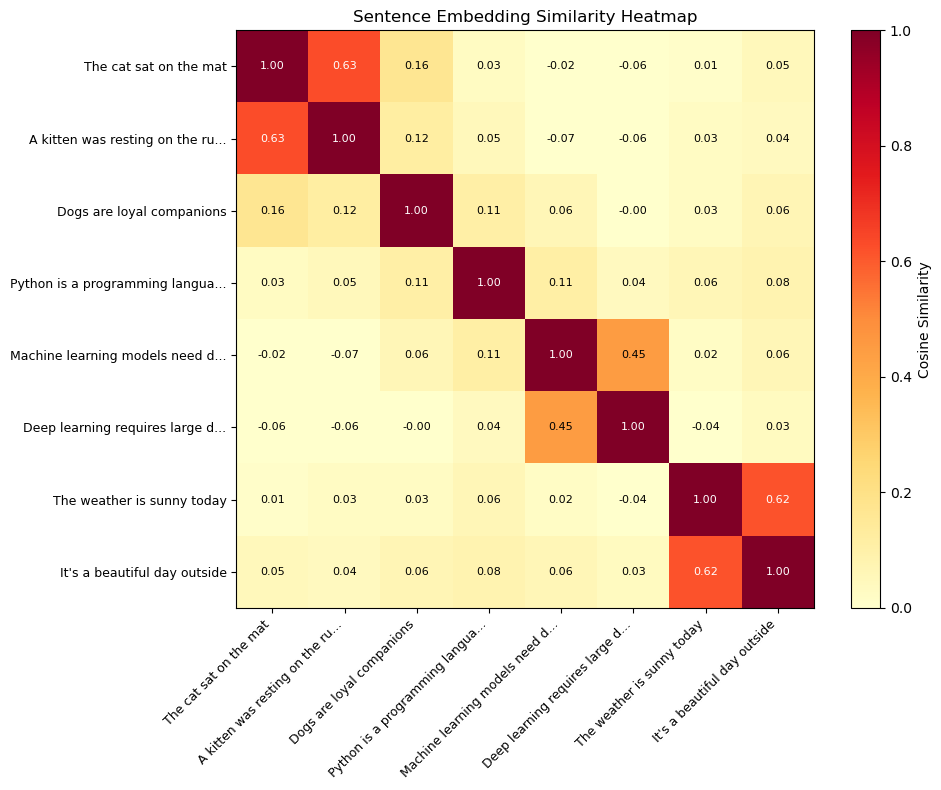


Key observations:
  'cat on mat' vs 'kitten on rug': 0.627 (high - similar meaning!)
  'cat on mat' vs 'Python programming': 0.031 (low - unrelated)
  'ML needs data' vs 'DL needs datasets': 0.447 (high - related topics)


In [3]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between all pairs
similarity_matrix = cosine_similarity(embeddings)

# Create a heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1)

# Add labels
short_labels = [s[:30] + "..." if len(s) > 30 else s for s in sentences]
ax.set_xticks(range(len(sentences)))
ax.set_yticks(range(len(sentences)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

# Add similarity values in cells
for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax.text(j, i, f'{similarity_matrix[i][j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if similarity_matrix[i][j] > 0.6 else 'black')

plt.colorbar(im, label='Cosine Similarity')
plt.title('Sentence Embedding Similarity Heatmap')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  'cat on mat' vs 'kitten on rug': {similarity_matrix[0][1]:.3f} (high - similar meaning!)")
print(f"  'cat on mat' vs 'Python programming': {similarity_matrix[0][3]:.3f} (low - unrelated)")
print(f"  'ML needs data' vs 'DL needs datasets': {similarity_matrix[4][5]:.3f} (high - related topics)")

---

### 🔧 Exercise 2: Building a Vector Store with FAISS

FAISS (Facebook AI Similarity Search) is a library for efficient similarity search. Let's build a simple knowledge base and search it.

In [4]:
import faiss

# Create a small knowledge base about countries
documents = [
    "Japan is an island nation in East Asia known for its technology and traditional culture.",
    "Brazil is the largest country in South America, famous for the Amazon rainforest and football.",
    "France is a Western European country known for the Eiffel Tower, wine, and cuisine.",
    "Australia is both a country and a continent, known for unique wildlife like kangaroos.",
    "Egypt is home to the ancient pyramids and the Nile River in North Africa.",
    "Canada is the second largest country by area, known for cold winters and maple syrup.",
    "India is a South Asian country with over 1.4 billion people and diverse cultures.",
    "Germany is a European country known for engineering, beer, and Oktoberfest.",
    "Kenya is an East African country famous for wildlife safaris and the Great Rift Valley.",
    "Singapore is a small but wealthy city-state in Southeast Asia known for its cleanliness.",
]

# Generate embeddings for all documents
doc_embeddings = model.encode(documents)
print(f"Document embeddings shape: {doc_embeddings.shape}")

# Create a FAISS index
dimension = doc_embeddings.shape[1]  # 384 for MiniLM
index = faiss.IndexFlatL2(dimension)  # L2 (Euclidean) distance
index.add(doc_embeddings.astype('float32'))

print(f"FAISS index created with {index.ntotal} vectors")

Document embeddings shape: (10, 384)
FAISS index created with 10 vectors


In [5]:
def search_faiss(query, model, index, documents, top_k=3):
    """Search the FAISS index for documents similar to the query."""
    query_embedding = model.encode([query]).astype('float32')
    distances, indices = index.search(query_embedding, top_k)

    print(f"Query: '{query}'\n")
    print(f"Top {top_k} results:")
    print("-" * 60)
    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), 1):
        similarity = 1 / (1 + dist)  # Convert distance to similarity score
        print(f"  {rank}. [{similarity:.3f}] {documents[idx]}")
    print()

# Test with different queries
search_faiss("What country has kangaroos?", model, index, documents)
search_faiss("Tell me about Asian technology", model, index, documents)
search_faiss("Where can I see pyramids?", model, index, documents)

Query: 'What country has kangaroos?'

Top 3 results:
------------------------------------------------------------
  1. [0.621] Australia is both a country and a continent, known for unique wildlife like kangaroos.
  2. [0.439] Kenya is an East African country famous for wildlife safaris and the Great Rift Valley.
  3. [0.427] Brazil is the largest country in South America, famous for the Amazon rainforest and football.



Query: 'Tell me about Asian technology'

Top 3 results:
------------------------------------------------------------
  1. [0.513] Japan is an island nation in East Asia known for its technology and traditional culture.
  2. [0.459] India is a South Asian country with over 1.4 billion people and diverse cultures.
  3. [0.443] Singapore is a small but wealthy city-state in Southeast Asia known for its cleanliness.

Query: 'Where can I see pyramids?'

Top 3 results:
------------------------------------------------------------
  1. [0.506] Egypt is home to the ancient pyramids and the Nile River in North Africa.
  2. [0.392] Kenya is an East African country famous for wildlife safaris and the Great Rift Valley.
  3. [0.366] France is a Western European country known for the Eiffel Tower, wine, and cuisine.



---

### 🔧 Exercise 3: Using ChromaDB

ChromaDB provides a higher-level API with built-in metadata support. Let's use the same documents.

In [6]:
import chromadb

# Create a ChromaDB client (in-memory for this exercise)
client = chromadb.Client()

# Create a collection (like a table in a database)
collection = client.create_collection(
    name="countries",
    metadata={"description": "Country facts knowledge base"}
)

# Add documents with metadata
for i, doc in enumerate(documents):
    collection.add(
        documents=[doc],
        ids=[f"doc_{i}"],
        metadatas=[{"region": ["Asia", "South America", "Europe", "Oceania", "Africa",
                               "North America", "Asia", "Europe", "Africa", "Asia"][i],
                    "index": i}]
    )

print(f"ChromaDB collection created with {collection.count()} documents")

ChromaDB collection created with 10 documents


In [7]:
# Search ChromaDB
results = collection.query(
    query_texts=["What country has unique wildlife?"],
    n_results=3
)

print("Query: 'What country has unique wildlife?'\n")
for i, (doc, dist, meta) in enumerate(zip(
    results['documents'][0], results['distances'][0], results['metadatas'][0]
)):
    print(f"  {i+1}. [dist: {dist:.3f}] ({meta['region']}) {doc}")

# Filter by metadata - only search in Asia
print("\n--- Filtered search (Asia only) ---\n")
results_asia = collection.query(
    query_texts=["Tell me about this country"],
    n_results=3,
    where={"region": "Asia"}
)
for i, (doc, meta) in enumerate(zip(results_asia['documents'][0], results_asia['metadatas'][0])):
    print(f"  {i+1}. ({meta['region']}) {doc}")

Query: 'What country has unique wildlife?'

  1. [dist: 0.799] (Oceania) Australia is both a country and a continent, known for unique wildlife like kangaroos.
  2. [dist: 1.138] (Africa) Kenya is an East African country famous for wildlife safaris and the Great Rift Valley.
  3. [dist: 1.183] (South America) Brazil is the largest country in South America, famous for the Amazon rainforest and football.

--- Filtered search (Asia only) ---

  1. (Asia) India is a South Asian country with over 1.4 billion people and diverse cultures.
  2. (Asia) Singapore is a small but wealthy city-state in Southeast Asia known for its cleanliness.
  3. (Asia) Japan is an island nation in East Asia known for its technology and traditional culture.


---

## Part B: LangChain Fundamentals (~60 min)

---

### 🔧 Exercise 4: LangChain Basics

Let's set up LangChain with a local LLM using Ollama.

⚠️ **Important:** Make sure Ollama is installed and running. If you haven't installed it yet, visit https://ollama.ai and download it, then run `ollama pull llama3.2:1b` in a terminal.

**Alternative:** If you have AWS Bedrock access, you can use `ChatBedrock` instead (instructions provided in comments).

In [8]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Option 1: Use Ollama (local, free)
llm = Ollama(model="llama3.2:1b")

# Option 2: Use AWS Bedrock (uncomment if you have access)
# from langchain_aws import ChatBedrock
# llm = ChatBedrock(model_id="anthropic.claude-3-haiku-20240307-v1:0")

# Test the LLM
response = llm.invoke("What is machine learning in one sentence?")
print("LLM Response:", response)

/var/folders/nt/0frtr2cj2g741ct6d2zgzks80000gn/T/ipykernel_11388/4198796431.py:6: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="llama3.2:1b")


ConnectionError: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x3538eaff0>: Failed to establish a new connection: [Errno 61] Connection refused'))

In [9]:
# Create a prompt template
prompt = PromptTemplate(
    input_variables=["topic"],
    template="Explain {topic} in simple terms for a beginner. Keep it to 2-3 sentences."
)

# Create a chain: prompt -> LLM -> parse output
chain = prompt | llm | StrOutputParser()

# Run the chain
result = chain.invoke({"topic": "retrieval-augmented generation"})
print("Chain output:")
print(result)

ConnectionError: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x3575536b0>: Failed to establish a new connection: [Errno 61] Connection refused'))

---

### 🔧 Exercise 5: Document Loading and Splitting

Let's create sample documents and practice loading and splitting them.

In [10]:
# Create sample text files for our knowledge base
import os
os.makedirs("knowledge_base", exist_ok=True)

# Document 1: Company FAQ
with open("knowledge_base/company_faq.txt", "w") as f:
    f.write("""Acme Corporation - Frequently Asked Questions

Q: What does Acme Corporation do?
A: Acme Corporation is a technology company that develops AI-powered solutions for businesses. Founded in 2020, we specialise in natural language processing, computer vision, and predictive analytics.

Q: Where is Acme Corporation headquartered?
A: Our headquarters is in Singapore, with additional offices in Tokyo, London, and San Francisco.

Q: What products does Acme offer?
A: Our main products include: AcmeChat (an AI customer service chatbot), AcmeVision (an image recognition platform), and AcmePredict (a predictive analytics tool for business forecasting).

Q: How many employees does Acme have?
A: As of 2024, Acme Corporation has approximately 500 employees across all offices.

Q: What is Acme's pricing model?
A: We offer tiered pricing: Starter (free for up to 1000 API calls/month), Professional ($99/month for up to 50,000 calls), and Enterprise (custom pricing for unlimited usage).

Q: How can I contact support?
A: You can reach our support team at support@acme.ai, through our website chat, or by calling +65 1234 5678 during business hours (9 AM - 6 PM SGT).
""")

# Document 2: Product Manual
with open("knowledge_base/product_manual.txt", "w") as f:
    f.write("""AcmeChat Product Manual - Version 3.0

Chapter 1: Getting Started
AcmeChat is an AI-powered customer service chatbot that can handle common customer enquiries automatically. It uses advanced natural language understanding to interpret customer messages and provide accurate responses.

Chapter 2: Setup and Configuration
To set up AcmeChat, you need to: 1) Create an account at dashboard.acme.ai, 2) Generate an API key from the Settings page, 3) Install the AcmeChat widget on your website using our JavaScript snippet, 4) Configure your knowledge base by uploading FAQs and product documentation.

Chapter 3: Training Your Chatbot
AcmeChat learns from your uploaded documents and conversation history. To improve accuracy: upload comprehensive FAQs, review and correct misclassified conversations weekly, add custom intents for industry-specific terminology, and regularly update your knowledge base.

Chapter 4: Integration Options
AcmeChat integrates with: Slack, Microsoft Teams, WhatsApp Business, Facebook Messenger, and any website via JavaScript widget. API integration is also available for custom applications.

Chapter 5: Analytics and Reporting
The AcmeChat dashboard provides: conversation volume metrics, customer satisfaction scores, resolution rates, common topics and trends, and agent handoff statistics.
""")

print("Knowledge base created with 2 documents")
print("Files:", os.listdir("knowledge_base"))

Knowledge base created with 2 documents
Files: ['product_manual.txt', 'company_faq.txt']


In [11]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Load all text files from the directory
loader = DirectoryLoader("knowledge_base", glob="*.txt", loader_cls=TextLoader)
documents = loader.load()

print(f"Loaded {len(documents)} documents")
for doc in documents:
    print(f"  - {doc.metadata['source']}: {len(doc.page_content)} characters")

# Split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,        # Max characters per chunk
    chunk_overlap=50,      # Overlap between chunks
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)

chunks = text_splitter.split_documents(documents)
print(f"\nSplit into {len(chunks)} chunks")
print(f"\nExample chunk (first one):")
print("-" * 40)
print(chunks[0].page_content[:300])
print("...")

ModuleNotFoundError: No module named 'langchain.text_splitter'

In [12]:
# Experiment with different chunk sizes
for chunk_size in [200, 500, 1000]:
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=50)
    result = splitter.split_documents(documents)
    print(f"Chunk size {chunk_size}: {len(result)} chunks")

NameError: name 'RecursiveCharacterTextSplitter' is not defined

---

## Part C: Building a Complete RAG System (~90 min)

---

### 🔧 Exercise 6: Simple RAG Pipeline

Now we'll put everything together to build a complete RAG system!

In [13]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS as LangchainFAISS
from langchain.chains import RetrievalQA

# Step 1: Load and split documents (already done above)
print(f"Documents loaded: {len(documents)}")
print(f"Chunks created: {len(chunks)}")

# Step 2: Create embeddings model
embeddings_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

# Step 3: Create vector store from chunks
vectorstore = LangchainFAISS.from_documents(chunks, embeddings_model)
print(f"\nVector store created with {vectorstore.index.ntotal} vectors")

# Step 4: Create a retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}  # Return top 3 most relevant chunks
)

print("Retriever ready!")

ModuleNotFoundError: No module named 'langchain.chains'

In [14]:
# Step 5: Build the RAG chain
from langchain_core.prompts import ChatPromptTemplate

# Create a prompt template that instructs the LLM to use the retrieved context
rag_prompt = ChatPromptTemplate.from_template("""Answer the question based only on the following context.
If you cannot find the answer in the context, say "I don't have enough information to answer that question."

Context:
{context}

Question: {question}

Answer:""")

# Create the chain
from langchain_core.runnables import RunnablePassthrough

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print("RAG chain built successfully!")

NameError: name 'retriever' is not defined

In [15]:
# Step 6: Ask questions!
questions = [
    "What products does Acme offer?",
    "How much does the Professional plan cost?",
    "How do I set up AcmeChat?",
    "What messaging platforms does AcmeChat integrate with?",
]

for q in questions:
    print(f"Q: {q}")
    answer = rag_chain.invoke(q)
    print(f"A: {answer}")
    print("-" * 60)

Q: What products does Acme offer?


NameError: name 'rag_chain' is not defined

In [16]:
# Test with a question NOT in the documents
print("Testing with out-of-scope question:\n")
answer = rag_chain.invoke("What is the weather like in Singapore?")
print(f"Q: What is the weather like in Singapore?")
print(f"A: {answer}")
print("\n(The model should indicate it doesn't have this information)")

Testing with out-of-scope question:



NameError: name 'rag_chain' is not defined

---

### 🔧 Exercise 7: Improving the RAG System

Let's experiment with parameters to improve our RAG system.

In [17]:
# Experiment 1: Different chunk sizes
print("=== Effect of Chunk Size on Retrieval ===\n")

query = "What is Acme's pricing?"

for chunk_size in [200, 500, 1000]:
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=50)
    test_chunks = splitter.split_documents(documents)
    test_vs = LangchainFAISS.from_documents(test_chunks, embeddings_model)
    results = test_vs.similarity_search(query, k=2)
    print(f"Chunk size: {chunk_size} ({len(test_chunks)} chunks)")
    for r in results:
        print(f"  → {r.page_content[:100]}...")
    print()

=== Effect of Chunk Size on Retrieval ===



NameError: name 'RecursiveCharacterTextSplitter' is not defined

In [18]:
# Experiment 2: Source attribution - show which chunks were used
print("=== RAG with Source Attribution ===\n")

query = "How can I contact Acme support?"
retrieved_docs = retriever.invoke(query)

print(f"Q: {query}\n")
print("Retrieved chunks:")
for i, doc in enumerate(retrieved_docs, 1):
    source = doc.metadata.get('source', 'unknown')
    print(f"  Chunk {i} (from {source}):")
    print(f"    {doc.page_content[:150]}...")
    print()

# Generate answer with the context
answer = rag_chain.invoke(query)
print(f"Answer: {answer}")

=== RAG with Source Attribution ===



NameError: name 'retriever' is not defined

---

## Part D: LlamaIndex Quick Start (~30 min)

---

### 🔧 Exercise 8: LlamaIndex Basics

Let's try the same task with LlamaIndex to see how it compares to LangChain.

In [19]:
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.ollama import Ollama as LlamaOllama

# Configure LlamaIndex settings
Settings.embed_model = HuggingFaceEmbedding(model_name="all-MiniLM-L6-v2")
Settings.llm = LlamaOllama(model="llama3.2:1b", request_timeout=120)

# Load documents (LlamaIndex has its own loader)
li_documents = SimpleDirectoryReader("knowledge_base").load_data()
print(f"LlamaIndex loaded {len(li_documents)} documents")

# Create index (this embeds and indexes all documents in one step!)
index = VectorStoreIndex.from_documents(li_documents)
print("Index created!")

# Create query engine
query_engine = index.as_query_engine(similarity_top_k=3)
print("Query engine ready!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

LlamaIndex loaded 2 documents


Index created!


ConnectionError: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download

In [20]:
# Ask the same questions we used with LangChain
questions = [
    "What products does Acme offer?",
    "How much does the Professional plan cost?",
    "What integrations does AcmeChat support?",
]

print("=== LlamaIndex RAG Results ===\n")
for q in questions:
    response = query_engine.query(q)
    print(f"Q: {q}")
    print(f"A: {response}")
    print("-" * 60)

=== LlamaIndex RAG Results ===



NameError: name 'query_engine' is not defined

---

## Recap and Key Takeaways

### What We Built Today

| Part | What We Did |
|------|-------------|
| **Part A** | Generated embeddings, built FAISS and ChromaDB vector stores, performed similarity search |
| **Part B** | Set up LangChain with Ollama, loaded documents, split into chunks |
| **Part C** | Built a complete RAG pipeline — from documents to grounded answers |
| **Part D** | Tried LlamaIndex as an alternative framework |

### RAG Architecture Summary

```
Documents → Chunking → Embeddings → Vector Store
                                         ↓
User Question → Embedding → Similarity Search → Top-K Chunks
                                                      ↓
                                        Prompt + Chunks → LLM → Answer
```

### RAG vs Fine-Tuning

| Aspect | RAG | Fine-Tuning |
|--------|-----|-------------|
| **Setup time** | Minutes to hours | Hours to days |
| **Data updates** | Add/remove docs instantly | Retrain needed |
| **Cost** | Low (no GPU training) | High (GPU required) |
| **Best for** | Factual Q&A, search, chatbots | Style/behaviour changes |
| **Transparency** | Can show source documents | Black box |

### Next: Session 6 — Assessment

The assessment will test your understanding of all Module 5 topics:
- **Part A:** Short-answer questions covering Sessions 1-5
- **Part B:** Practical component — deploying a model to AWS SageMaker

---

*End of Session 5: Implementing RAG*

*Module 5: Deep Learning in Production | SMU Advanced Certificate in Generative AI and Deep Learning*

In [21]:
# Optional: Clean up created files
import shutil
if os.path.exists("knowledge_base"):
    shutil.rmtree("knowledge_base")
    print("Cleaned up knowledge_base/")

Cleaned up knowledge_base/
